# Paper 016 — HMM Forward / Backward / Viterbi for Genomic Inference

**Kevin Liu & Luay Nakhleh (2014).** [*An HMM-based Comparative Genomic Framework for Detecting Introgression in the Presence of Incomplete Lineage Sorting*](https://doi.org/10.1371/journal.pcbi.1003649). *PLoS Computational Biology* **10(4)**, e1003649.

## Abstract (compressed)

The paper introduces a phylogenetic hidden Markov model (**PhyloNet-HMM**) to detect **introgression** (gene flow between species) from genomic alignments while accounting for incomplete lineage sorting. The computational core is standard discrete HMM inference: **forward** $\alpha_t(i)=P(o_1\ldots o_t,s_t=i)$ as a matrix–vector multiply chain, **backward** $\beta$, **Viterbi** decoding (max replaces sum), and **Baum–Welch (EM)** for parameter estimation.

### BarraCUDA connection

Forward/backward steps are **GEMM-shaped** state updates (`gemm_f64.wgsl`); Viterbi pairs **max** reductions with **argmax** (`reduce_max.wgsl`); Baum–Welch reuses the same primitives for expected counts / outer products.

**Implementation:** self-contained `numpy` port of `control/hmm_phylo/hmm_phylo.py` plus **Baum–Welch EM** (inline).

**Provenance:** `src/provenance/experiments.rs` — `HMM_PROVENANCE`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

PASS = '#2ecc71'
FAIL = '#e74c3c'
INFO = '#3498db'

SEED = 42
rng_global = np.random.default_rng(SEED)
np.random.seed(SEED)


## Discrete HMM: forward, backward (scaled), Viterbi, posterior

Scaling avoids underflow over long genomic windows; $\log$ likelihood aggregates $\log c_t$ from scale factors.


In [2]:
class HiddenMarkovModel:
    """Discrete HMM: N hidden states, M observation symbols."""

    def __init__(self, transition: np.ndarray, emission: np.ndarray, initial: np.ndarray):
        self.A = np.array(transition, dtype=np.float64)
        self.B = np.array(emission, dtype=np.float64)
        self.pi = np.array(initial, dtype=np.float64)
        self.N = self.A.shape[0]
        self.M = self.B.shape[1]

    def forward(self, observations: np.ndarray) -> tuple[np.ndarray, float, np.ndarray]:
        """Scaled forward; returns alpha, log-likelihood, scale factors c_t."""
        T = len(observations)
        alpha = np.zeros((T, self.N))
        scales = np.zeros(T)
        alpha[0] = self.pi * self.B[:, observations[0]]
        scales[0] = alpha[0].sum()
        alpha[0] /= scales[0] + 1e-300
        for t in range(1, T):
            alpha[t] = (alpha[t - 1] @ self.A) * self.B[:, observations[t]]
            scales[t] = alpha[t].sum()
            if scales[t] > 0:
                alpha[t] /= scales[t]
        log_lik = float(np.sum(np.log(scales + 1e-300)))
        return alpha, log_lik, scales

    def backward(self, observations: np.ndarray, scales: np.ndarray) -> np.ndarray:
        T = len(observations)
        beta = np.zeros((T, self.N))
        beta[-1] = 1.0
        for t in range(T - 2, -1, -1):
            beta[t] = self.A @ (self.B[:, observations[t + 1]] * beta[t + 1])
            if scales[t + 1] > 0:
                beta[t] /= scales[t + 1]
        return beta

    def viterbi(self, observations: np.ndarray) -> tuple[np.ndarray, float]:
        T = len(observations)
        log_A = np.log(self.A + 1e-300)
        log_B = np.log(self.B + 1e-300)
        log_pi = np.log(self.pi + 1e-300)
        delta = np.zeros((T, self.N))
        psi = np.zeros((T, self.N), dtype=int)
        delta[0] = log_pi + log_B[:, observations[0]]
        for t in range(1, T):
            for j in range(self.N):
                candidates = delta[t - 1] + log_A[:, j]
                psi[t, j] = np.argmax(candidates)
                delta[t, j] = candidates[psi[t, j]] + log_B[j, observations[t]]
        path = np.zeros(T, dtype=int)
        path[-1] = np.argmax(delta[-1])
        log_prob = float(delta[-1, path[-1]])
        for t in range(T - 2, -1, -1):
            path[t] = psi[t + 1, path[t + 1]]
        return path, log_prob

    def posterior(self, observations: np.ndarray) -> np.ndarray:
        alpha, _, scales = self.forward(observations)
        beta = self.backward(observations, scales)
        gamma = alpha * beta
        row_sums = gamma.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        gamma /= row_sums
        return gamma


## Baum–Welch (EM): one M-step from expected counts

Expectation uses $\gamma_t(i)$ and $\xi_t(i,j)$ from scaled $\alpha,\beta$; maximization updates $\pi$, **A**, **B** (tied rows stay valid probability vectors).


In [3]:
def compute_gamma_xi(
    hmm: HiddenMarkovModel, obs: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """Posterior state and transition expectations for one sequence."""
    alpha, _, scales = hmm.forward(obs)
    beta = hmm.backward(obs, scales)
    T = len(obs)
    N = hmm.N
    gamma = alpha * beta
    gamma /= gamma.sum(axis=1, keepdims=True) + 1e-300
    xi = np.zeros((T - 1, N, N))
    for t in range(T - 1):
        denom = 0.0
        for i in range(N):
            for j in range(N):
                denom += alpha[t, i] * hmm.A[i, j] * hmm.B[j, obs[t + 1]] * beta[t + 1, j]
        denom = denom + 1e-300
        for i in range(N):
            for j in range(N):
                xi[t, i, j] = (
                    alpha[t, i] * hmm.A[i, j] * hmm.B[j, obs[t + 1]] * beta[t + 1, j]
                ) / denom
    return gamma, xi


def baum_welch_step(hmm: HiddenMarkovModel, obs: np.ndarray) -> HiddenMarkovModel:
    """Single EM update from one observation sequence."""
    T = len(obs)
    N, M = hmm.N, hmm.M
    gamma, xi = compute_gamma_xi(hmm, obs)
    pi_new = gamma[0].copy()
    A_new = np.zeros((N, N))
    for i in range(N):
        denom = gamma[:-1, i].sum() + 1e-300
        for j in range(N):
            A_new[i, j] = xi[:, i, j].sum() / denom
    A_new /= A_new.sum(axis=1, keepdims=True) + 1e-300
    B_new = np.zeros((N, M))
    for k in range(M):
        mask = obs == k
        B_new[:, k] = (gamma[mask]).sum(axis=0) if mask.any() else 0.0
    B_new /= B_new.sum(axis=1, keepdims=True) + 1e-300
    return HiddenMarkovModel(A_new, B_new, pi_new)


def run_baum_welch(
    hmm: HiddenMarkovModel, obs: np.ndarray, n_iter: int = 25
) -> tuple[HiddenMarkovModel, np.ndarray]:
    """EM iterations; returns model and log-likelihood trace."""
    ll = np.zeros(n_iter)
    cur = hmm
    for it in range(n_iter):
        _, ll[it], _ = cur.forward(obs)
        cur = baum_welch_step(cur, obs)
    return cur, ll


## Factory HMMs & sequence simulation


In [4]:
def create_weather_hmm() -> tuple[HiddenMarkovModel, dict]:
    A = np.array([[0.7, 0.3], [0.4, 0.6]])
    B = np.array([[0.1, 0.4, 0.5], [0.6, 0.3, 0.1]])
    pi = np.array([0.6, 0.4])
    meta = {
        "states": ["Sunny", "Rainy"],
        "observations": ["Walk", "Shop", "Clean"],
    }
    return HiddenMarkovModel(A, B, pi), meta


def create_phylo_hmm(n_states: int = 4, n_symbols: int = 4, seed: int = 42) -> HiddenMarkovModel:
    rng = np.random.default_rng(seed)
    A = rng.dirichlet(np.ones(n_states) * 10, size=n_states)
    B = rng.dirichlet(np.ones(n_symbols) * 2, size=n_states)
    pi = rng.dirichlet(np.ones(n_states) * 5)
    return HiddenMarkovModel(A, B, pi)


def generate_hmm_sequence(
    hmm: HiddenMarkovModel, length: int, seed: int = 42
) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    states = np.zeros(length, dtype=int)
    observations = np.zeros(length, dtype=int)
    states[0] = rng.choice(hmm.N, p=hmm.pi)
    observations[0] = rng.choice(hmm.M, p=hmm.B[states[0]])
    for t in range(1, length):
        states[t] = rng.choice(hmm.N, p=hmm.A[states[t - 1]])
        observations[t] = rng.choice(hmm.M, p=hmm.B[states[t]])
    return states, observations


## Visualizations: scaled forward surface & posterior heatmap


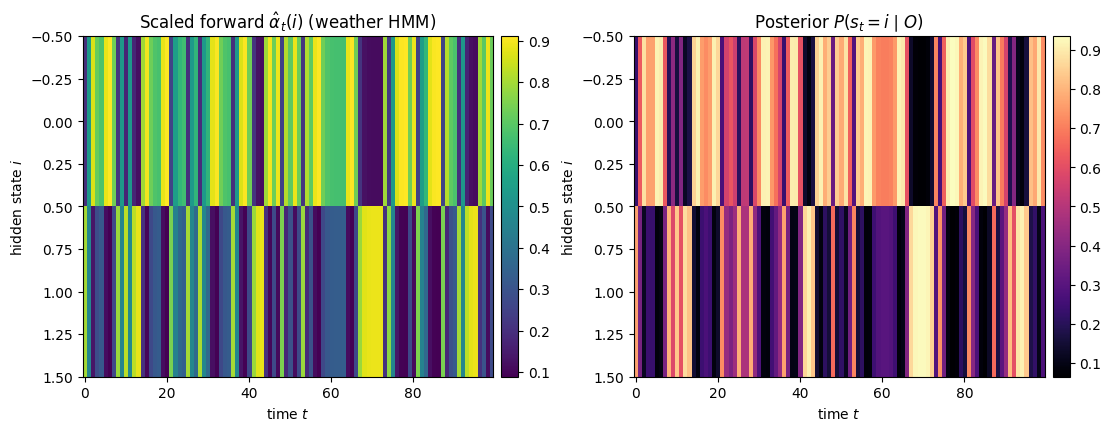

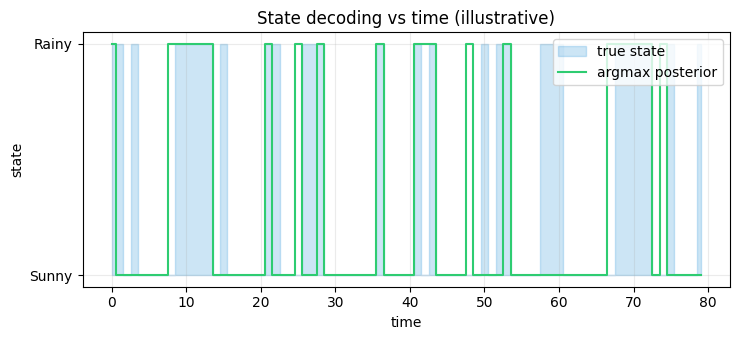

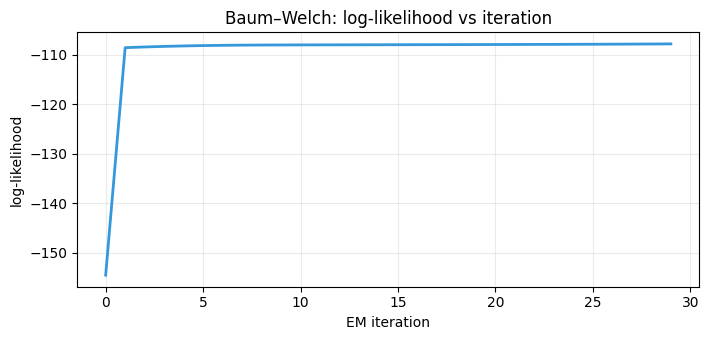

In [5]:
hmm_demo, meta_demo = create_weather_hmm()
true_states, gen_obs = generate_hmm_sequence(hmm_demo, 100, seed=SEED)
alpha_demo, log_lik_demo, scales_demo = hmm_demo.forward(gen_obs)
gamma_demo = hmm_demo.posterior(gen_obs)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
im0 = axes[0].imshow(alpha_demo.T, aspect='auto', cmap='viridis', interpolation='nearest')
axes[0].set_title('Scaled forward $\hat\\alpha_t(i)$ (weather HMM)')
axes[0].set_xlabel('time $t$')
axes[0].set_ylabel('hidden state $i$')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.02)

im1 = axes[1].imshow(gamma_demo.T, aspect='auto', cmap='magma', interpolation='nearest')
axes[1].set_title('Posterior $P(s_t=i \\mid O)$')
axes[1].set_xlabel('time $t$')
axes[1].set_ylabel('hidden state $i$')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.02)
plt.show()

fig2, ax = plt.subplots(figsize=(7.5, 3.5))
t_ix = np.arange(min(80, len(gen_obs)))
ax.fill_between(t_ix, 0, true_states[: len(t_ix)], color=INFO, alpha=0.25, step='mid', label='true state')
ax.step(t_ix, np.argmax(gamma_demo, axis=1)[: len(t_ix)], where='mid', color=PASS, label='argmax posterior')
ax.set_yticks([0, 1])
ax.set_yticklabels(meta_demo['states'])
ax.set_xlabel('time')
ax.set_ylabel('state')
ax.set_title('State decoding vs time (illustrative)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# EM log-likelihood curve (random initial model, same obs)
rng_em = np.random.default_rng(7)
N_em, M_em = 3, 4
A0 = rng_em.dirichlet(np.ones(N_em), size=N_em)
B0 = rng_em.dirichlet(np.ones(M_em) * 2, size=N_em)
pi0 = rng_em.dirichlet(np.ones(N_em) * 2)
em_hmm = HiddenMarkovModel(A0, B0, pi0)
short_obs = gen_obs[:120]
_, ll_trace = run_baum_welch(em_hmm, short_obs, n_iter=30)
plt.figure(figsize=(7.2, 3.5))
plt.plot(np.arange(len(ll_trace)), ll_trace, color=INFO, linewidth=2)
plt.xlabel('EM iteration')
plt.ylabel('log-likelihood')
plt.title('Baum–Welch: log-likelihood vs iteration')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [6]:
# --- Validation suite (10 checks) ---
passed = 0
failed = 0

hmm, meta = create_weather_hmm()
obs = np.array([0, 1, 2, 0, 2])

alpha, log_lik, scales = hmm.forward(obs)
if np.isfinite(log_lik) and log_lik < 0:
    print('PASS  Forward: finite negative log-likelihood')
    passed += 1
else:
    print(f'FAIL  Forward: log_lik={log_lik}')
    failed += 1

alpha_sums = alpha.sum(axis=1)
if np.allclose(alpha_sums, 1.0, atol=1e-10):
    print('PASS  Forward: scaled alpha sums to 1 per time')
    passed += 1
else:
    print(f'FAIL  Forward: alpha row sums={alpha_sums}')
    failed += 1

true_states, gen_obs_v = generate_hmm_sequence(hmm, 100, seed=42)
viterbi_path, viterbi_prob = hmm.viterbi(gen_obs_v)
accuracy = np.mean(viterbi_path == true_states)
chance = 1.0 / hmm.N
if accuracy > chance + 0.05:
    print(f'PASS  Viterbi accuracy ({accuracy:.4f}) > chance+0.05')
    passed += 1
else:
    print(f'FAIL  Viterbi accuracy ({accuracy:.4f})')
    failed += 1

if np.isfinite(viterbi_prob):
    print('PASS  Viterbi: finite log-probability')
    passed += 1
else:
    print('FAIL  Viterbi: non-finite log-probability')
    failed += 1

gamma = hmm.posterior(gen_obs_v)
if np.allclose(gamma.sum(axis=1), 1.0, atol=1e-8):
    print('PASS  Posterior rows sum to 1')
    passed += 1
else:
    print('FAIL  Posterior normalization')
    failed += 1

posterior_accuracy = np.mean(np.argmax(gamma, axis=1) == true_states)
if posterior_accuracy >= accuracy - 0.05:
    print('PASS  Posterior argmax comparable to Viterbi')
    passed += 1
else:
    print('FAIL  Posterior argmax much worse than Viterbi')
    failed += 1

phylo_hmm = create_phylo_hmm(n_states=4, n_symbols=4, seed=42)
true_phylo, phylo_obs = generate_hmm_sequence(phylo_hmm, 5000, seed=42)
_, phylo_loglik, phy_scales = phylo_hmm.forward(phylo_obs)
phylo_path, _ = phylo_hmm.viterbi(phylo_obs)
phylo_acc = np.mean(phylo_path == true_phylo)
phylo_chance = 1.0 / phylo_hmm.N
if np.isfinite(phylo_loglik):
    print('PASS  Phylo forward: finite log-lik at 5k sites')
    passed += 1
else:
    print('FAIL  Phylo forward underflow')
    failed += 1

if phylo_acc > phylo_chance + 0.02:
    print(f'PASS  Phylo Viterbi ({phylo_acc:.4f}) > chance+0.02')
    passed += 1
else:
    print(f'FAIL  Phylo Viterbi ({phylo_acc:.4f})')
    failed += 1

obs_short = gen_obs_v[:10]
alpha_manual = np.zeros((10, hmm.N))
alpha_manual[0] = hmm.pi * hmm.B[:, obs_short[0]]
alpha_manual[0] /= alpha_manual[0].sum()
for t in range(1, 10):
    alpha_manual[t] = (alpha_manual[t - 1] @ hmm.A) * hmm.B[:, obs_short[t]]
    alpha_manual[t] /= alpha_manual[t].sum()
alpha_lib, _, _ = hmm.forward(obs_short)
max_diff = np.max(np.abs(alpha_manual - alpha_lib))
if max_diff < 1e-12:
    print(f'PASS  Manual GEMM chain matches library forward (max |Δ|={max_diff:.2e})')
    passed += 1
else:
    print(f'FAIL  GEMM chain mismatch (max |Δ|={max_diff:.2e})')
    failed += 1

if ll_trace[-1] >= ll_trace[0] - 1e-6:
    print('PASS  Baum–Welch: log-likelihood non-decreasing over EM run')
    passed += 1
else:
    print('FAIL  EM log-likelihood decreased')
    failed += 1

print()
print(f'TOTAL  {passed}/{passed+failed} PASS, {failed}/{passed+failed} FAIL')


PASS  Forward: finite negative log-likelihood
PASS  Forward: scaled alpha sums to 1 per time
PASS  Viterbi accuracy (0.7700) > chance+0.05
PASS  Viterbi: finite log-probability
PASS  Posterior rows sum to 1
PASS  Posterior argmax comparable to Viterbi
PASS  Phylo forward: finite log-lik at 5k sites
PASS  Phylo Viterbi (0.3654) > chance+0.02
PASS  Manual GEMM chain matches library forward (max |Δ|=0.00e+00)
PASS  Baum–Welch: log-likelihood non-decreasing over EM run

TOTAL  10/10 PASS, 0/10 FAIL


## Summary

| # | Check | Result |
|---|--------|--------|
| 1 | Forward log-likelihood finite & negative | printed above |
| 2 | Scaled $\hat\alpha$ rows sum to 1 | printed above |
| 3 | Viterbi accuracy $>$ chance + 0.05 | printed above |
| 4 | Viterbi log-prob finite | printed above |
| 5 | Posterior rows sum to 1 | printed above |
| 6 | Posterior argmax comparable to Viterbi | printed above |
| 7 | Phylogenetic-scale forward stable | printed above |
| 8 | Phylogenetic Viterbi $>$ chance + 0.02 | printed above |
| 9 | Manual forward chain $=$ library | printed above |
| 10 | Baum–Welch monotonic log-likelihood | printed above |

### Provenance links

- Paper: [doi:10.1371/journal.pcbi.1003649](https://doi.org/10.1371/journal.pcbi.1003649)
- Code reference: `control/hmm_phylo/hmm_phylo.py`
- Registry: `src/provenance/experiments.rs` — `HMM_PROVENANCE`

[primals.eco](https://primals.eco) · neuralSpring Paper 016
